# Latent Space Exploration (Improved)

Explores the token space across different pitch representations.
Updates:
- Centralized pitch extraction for consistent color mapping across all plots.
- Visual improvements (magma colormap, scaled points, no edge colors) to clearly show clustering.

In [25]:
import sys, pathlib, os, glob, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import Normalize

# Setup paths
repo_root = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'latent_exploration' else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))

DATASET_PATHS = [
    "../trumpet_frequency",
    "../trumpet_class",
    "../trumpet_fourier",
    "../trumpet_log_normalised",
    "../trumpet_sine_cosine",
]
DATASET_LABELS = ["frequency", "class", "fourier", "log_norm", "sine_cosine"]

TOKEN_DIR  = "hf_dataset/tokens/train"
MAX_FRAMES = 6000   # subsample cap for PCA speed
TSNE_MAX   = 3000   # t-SNE is slower

print(f"Datasets: {DATASET_LABELS}")
plt.style.use('seaborn-v0_8-whitegrid')

Datasets: ['frequency', 'class', 'fourier', 'log_norm', 'sine_cosine']


## 1. Load Datasets

In [26]:
def load_ecdc(path):
    d = torch.load(path, map_location="cpu")
    codes = d["audio_codes"].squeeze(0).squeeze(0)
    return codes.T.float().numpy()

def load_cond(path, n_frames):
    cond = np.load(path).astype(np.float32)
    if cond.shape[0] == 0 or cond.shape[1] == 0: return None
    if len(cond) != n_frames:
        idx  = np.linspace(0, len(cond) - 1, n_frames).astype(int)
        cond = cond[idx]
    return cond

def load_conditioning_config(dataset_path):
    cfg_path = os.path.join(dataset_path, "hf_dataset", "conditioning_config.json")
    if os.path.exists(cfg_path):
        with open(cfg_path) as f:
            return json.load(f)
    return {}

def subsample(arr, max_n, seed=42):
    rng = np.random.default_rng(seed)
    if arr.shape[0] > max_n:
        idx = np.sort(rng.choice(arr.shape[0], max_n, replace=False))
        return arr[idx]
    return arr

DATASETS = {}
for dset_path, label in zip(DATASET_PATHS, DATASET_LABELS):
    token_dir = os.path.join(dset_path, TOKEN_DIR)
    if not os.path.exists(token_dir): continue

    cfg = load_conditioning_config(dset_path)
    ecdc_files = sorted(glob.glob(os.path.join(token_dir, "*.ecdc")))
    all_codes, all_cond = [], []

    for ecdc_path in ecdc_files:
        stem = os.path.splitext(os.path.basename(ecdc_path))[0]
        cond_path = os.path.join(token_dir, stem + ".cond.npy")
        if not os.path.exists(cond_path): continue

        codes = load_ecdc(ecdc_path)
        cond  = load_cond(cond_path, codes.shape[0])

        all_codes.append(codes)
        if cond is not None: all_cond.append(cond)

    if not all_codes: continue

    codes_np = np.vstack(all_codes)
    cond_np  = np.vstack(all_cond) if all_cond else None
    full_np  = np.hstack([codes_np, cond_np]) if cond_np is not None else codes_np

    DATASETS[label] = {"codes": codes_np, "cond": cond_np, "full": full_np, "cfg": cfg, "n_cond": cond_np.shape[1] if cond_np is not None else 0}
    print(f"{label:15s}  frames={codes_np.shape[0]:5d}  codes={codes_np.shape[1]}  cond={DATASETS[label]['n_cond']}  full={full_np.shape[1]}")

print(f"\nLoaded {len(DATASETS)} datasets.")

frequency        frames=52711  codes=8  cond=1  full=9
class            frames=52711  codes=8  cond=11  full=19
fourier          frames=52711  codes=8  cond=8  full=16
log_norm         frames=52711  codes=8  cond=1  full=9
sine_cosine      frames=52711  codes=8  cond=2  full=10

Loaded 5 datasets.


## 2. Centralized Pitch Extraction (For Color Mapping)

In [27]:
# --- 1. Define your specific class mapping ---
# Ensure this list matches the order of your one-hot vector indices
CLASS_NAMES = ["A#3", "A4", "C#4", "C4", "D#4", "D4", "E4", "F#4", "F4", "G#4", "G4"]

def note_to_hz(note_name):
    """Converts a note name (e.g., 'A4') to its frequency in Hz."""
    letter_map = {'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11}
    name = note_name[:-1]
    octave = int(note_name[-1])
    midi_num = (octave + 1) * 12 + letter_map[name]
    return 440.0 * (2.0 ** ((midi_num - 69.0) / 12.0))

CLASS_HZ_LOOKUP = np.array([note_to_hz(n) for n in CLASS_NAMES])

# --- 2. Updated to_hz_safe with One-Hot Support ---
def to_hz_safe(label, data, max_n=None):
    # Select conditioning array
    arr = data["cond"] if (data["cond"] is not None and data["n_cond"] > 0) else data["codes"]
    if max_n: 
        arr = subsample(arr, max_n)
    
    if "class" in label:
        # Check if it's one-hot (width > 1) or scalar index
        if arr.shape[1] > 1:
            indices = np.argmax(arr, axis=1) # Get index of the '1'
        else:
            indices = arr[:, 0].astype(int)  # Already a scalar index
        
        # Map indices to their corresponding Hz values
        indices = np.clip(indices, 0, len(CLASS_HZ_LOOKUP) - 1)
        return CLASS_HZ_LOOKUP[indices], True

    elif "frequency" in label:
        return FREQ_MIN + arr[:, 0] * (FREQ_MAX - FREQ_MIN), True
        
    elif "log" in label:
        return np.exp(np.log(FREQ_MIN) + arr[:, 0] * (np.log(FREQ_MAX) - np.log(FREQ_MIN))), True
        
    elif "sine_cosine" in label and arr.shape[1] >= 2:
        return np.arctan2(arr[:, 0], arr[:, 1]), False
        
    else:
        return arr[:, 0], False

# --- 3. Rebuild the Cache (IMPORTANT: Re-run this block) ---
hz_cache, is_true_pitch, true_hz_all = {}, {}, []
for label, data in DATASETS.items():
    hz, is_true = to_hz_safe(label, data, MAX_FRAMES)
    hz_cache[label], is_true_pitch[label] = hz, is_true
    if is_true: 
        true_hz_all.append(hz)
        print(f"Dataset '{label}' frequency range: {hz.min():.1f}Hz to {hz.max():.1f}Hz")

if true_hz_all:
    true_hz_all = np.concatenate(true_hz_all)
    # Use a slightly wider margin for the global scale to prevent clipping colors
    global_min, global_max = true_hz_all.min() - 2, true_hz_all.max() + 2
else:
    global_min, global_max = 230, 450

pitch_norm = Normalize(vmin=global_min, vmax=global_max)

def get_normalized_pitch(label, n_frames):
    hz = hz_cache[label][:n_frames]
    if not is_true_pitch[label]:
        hz = (hz - hz.min()) / (hz.max() - hz.min() + 1e-8)
        hz = global_min + hz * (global_max - global_min)
    return hz

Dataset 'frequency' frequency range: 237.9Hz to 446.1Hz
Dataset 'class' frequency range: 233.1Hz to 440.0Hz
Dataset 'log_norm' frequency range: 234.0Hz to 448.0Hz


## 3. PCA of Codebooks Only (Unclustered Pitch)

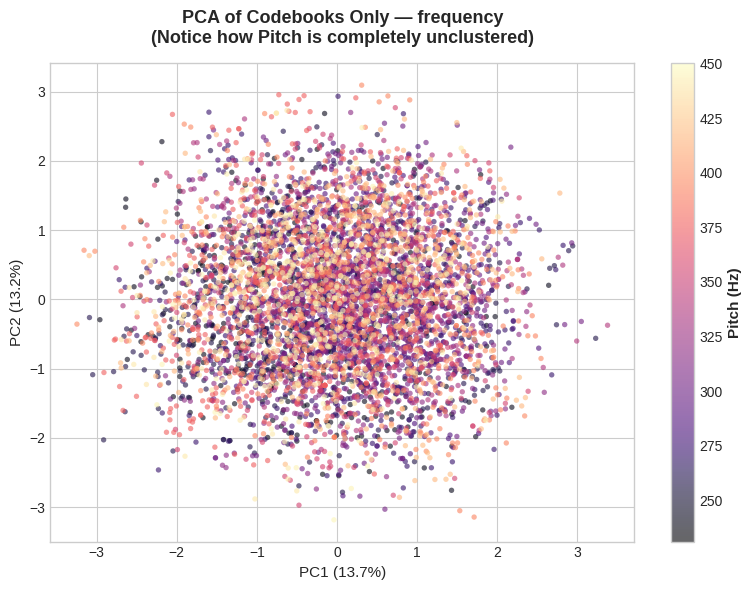

In [28]:
if DATASETS:
    label_a = list(DATASETS.keys())[0]
    codes_a = subsample(DATASETS[label_a]["codes"], MAX_FRAMES)
    hz_a = get_normalized_pitch(label_a, len(codes_a))
    
    pca_codes = PCA(n_components=2)
    codes_2d = pca_codes.fit_transform(StandardScaler().fit_transform(codes_a))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(codes_2d[:, 0], codes_2d[:, 1], c=hz_a, cmap="magma", 
                    norm=pitch_norm, alpha=0.6, s=15, edgecolor="none")
    
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Pitch (Hz)", fontsize=11, weight='bold')
    
    ax.set_title(f"PCA of Codebooks Only — {label_a}\n(Notice how Pitch is completely unclustered)", 
                 fontsize=13, weight='bold', pad=15)
    ax.set_xlabel(f"PC1 ({pca_codes.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC2 ({pca_codes.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
    
    plt.tight_layout()
    plt.show()

## 4. PCA of Full Tokens (Codebooks + Conditioning)

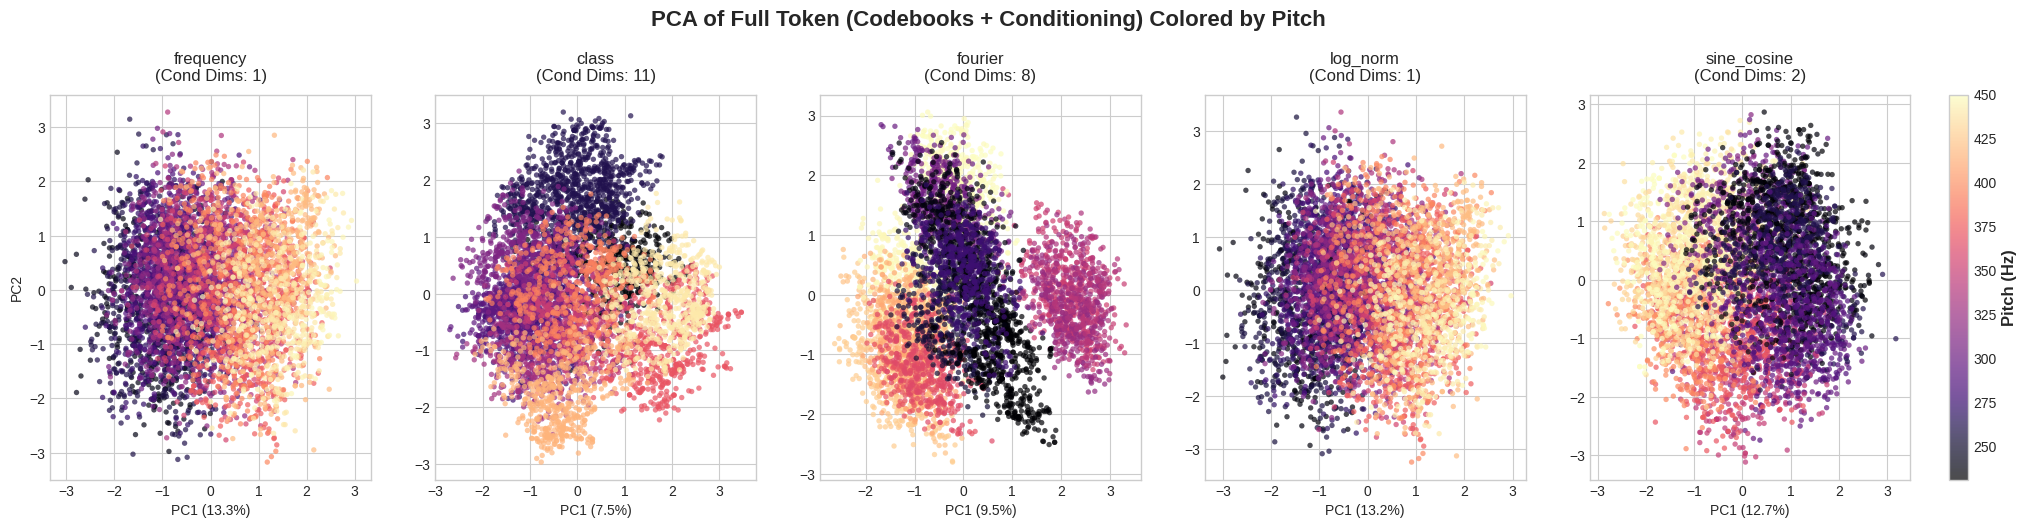

In [31]:
n_datasets = len(DATASETS)
if n_datasets > 0:
    fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5))
    if n_datasets == 1: axes = [axes]
    
    fig.suptitle("PCA of Full Token (Codebooks + Conditioning) Colored by Pitch", 
                 fontsize=16, weight='bold', y=1.05)
    
    for ax, (label, data) in zip(axes, DATASETS.items()):
        codes_scaled = StandardScaler().fit_transform(data["codes"])
        cond_scaled = StandardScaler().fit_transform(data["cond"]) if data["cond"] is not None else None
        full_scaled = np.hstack([codes_scaled, cond_scaled]) if cond_scaled is not None else codes_scaled
        
        full = subsample(full_scaled, MAX_FRAMES)
        hz = get_normalized_pitch(label, len(full))
    
        pca = PCA(n_components=2)
        t2d = pca.fit_transform(full)
    
        sc = ax.scatter(t2d[:, 0], t2d[:, 1], c=hz, cmap="magma", 
                        norm=pitch_norm, alpha=0.7, s=15, edgecolor="none")
    
        ax.set_title(f"{label}\n(Cond Dims: {data['n_cond']})", fontsize=12, pad=10)
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
        if ax == axes[0]: ax.set_ylabel("PC2")
    
    cbar = fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02)
    cbar.set_label("Pitch (Hz)", fontsize=12, weight='bold')
    
    plt.show()

## 5. t-SNE of Full Tokens

Running t-SNE for frequency...
Running t-SNE for class...
Running t-SNE for fourier...
Running t-SNE for log_norm...
Running t-SNE for sine_cosine...


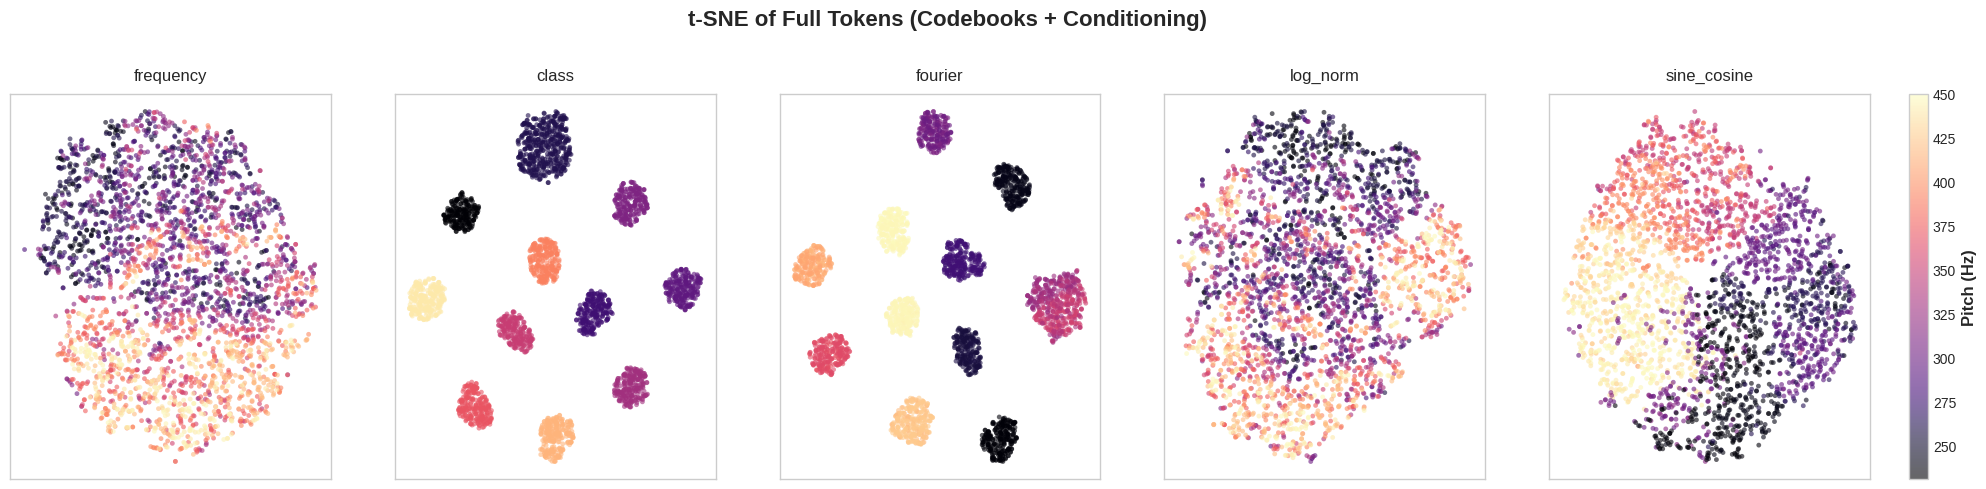

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Ensure we have our Hz boundaries defined
FREQ_MIN, FREQ_MAX = 234.0, 448.0

# 1. Prepare the figure
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5))
if n_datasets == 1: axes = [axes]
fig.suptitle("t-SNE of Full Tokens (Codebooks + Conditioning)", 
             fontsize=16, weight='bold', y=1.05)

for ax, (label, data) in zip(axes, DATASETS.items()):
    # Step A: Subsample for the t-SNE run
    full_sub = subsample(data["full"], TSNE_MAX)
    cond_sub = full_sub[:, 8:] # Conditioning starts after 8 codebooks
    
    # Step B: Extract Hz for coloring (Force all to Hz scale)
    if "class" in label:
        indices = np.argmax(cond_sub, axis=1)
        hz = CLASS_HZ_LOOKUP[np.clip(indices, 0, len(CLASS_HZ_LOOKUP)-1)]
    elif "frequency" in label:
        hz = FREQ_MIN + cond_sub[:, 0] * (FREQ_MAX - FREQ_MIN)
    elif "log" in label:
        hz = np.exp(np.log(FREQ_MIN) + cond_sub[:, 0] * (np.log(FREQ_MAX) - np.log(FREQ_MIN)))
    elif "sine_cosine" in label:
        # Reconstruct normalized pitch from sine/cosine and scale to Hz
        angle = np.arctan2(cond_sub[:, 0], cond_sub[:, 1])
        p_norm = (angle - angle.min()) / (angle.max() - angle.min() + 1e-8)
        hz = FREQ_MIN + p_norm * (FREQ_MAX - FREQ_MIN)
    else:
        # Fallback: scale whatever the first cond dim is to the Hz range
        val = cond_sub[:, 0]
        v_norm = (val - val.min()) / (val.max() - val.min() + 1e-8)
        hz = FREQ_MIN + v_norm * (FREQ_MAX - FREQ_MIN)

    print(f"Running t-SNE for {label}...")
    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    # Scale features (codebooks + cond) for better manifold distance
    t2d = tsne.fit_transform(StandardScaler().fit_transform(full_sub))

    # Step C: Plot with explicit Normalization
    sc = ax.scatter(t2d[:, 0], t2d[:, 1], c=hz, cmap="magma", 
                    norm=pitch_norm, alpha=0.6, s=12, edgecolor="none")
    
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xticks([]); ax.set_yticks([])

# Final Step: Add colorbar linked to the Hz normalization
cbar = fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("Pitch (Hz)", fontsize=12, weight='bold')

plt.show()